# Week 6 — First ML Mini-Project

## End-to-End Prediction Project

This is my first complete machine learning mini-project.

This project combines the full machine learning process:

Understand data → clean/check data → split data → train model → make predictions → evaluate model → conclude

For this project, I am using the Iris dataset from scikit-learn.

## Project Question

Can I predict the Iris flower species from sepal and petal measurements?

## Task Type

This is a classification task because the model is predicting a category.

The category is the Iris flower species.

# Part 1 — Learning Notes

## Full Machine Learning Pipeline

A full machine learning pipeline means following the complete process from data to prediction.

The main flow is:

Understand data → clean data → split data → train model → predict → evaluate → conclude

First, we understand what the dataset contains.  
Then we check if the data has missing values, duplicates, or other problems.  
After that, we split the data into training and test sets.  
The model learns from the training data.  
Then the model makes predictions on the test data.  
Finally, we evaluate the results and write an honest conclusion.

## Why Evaluation and Honesty Matter

A high accuracy number alone does not always mean the model is perfect.

A model should be evaluated honestly because real machine learning is not only about getting a good number. It is also about understanding where the model works well and where it may fail.

If we only focus on accuracy, we may miss important problems. For example, a model may perform well on one dataset but fail on new or messy real-world data.

## What Makes an ML Notebook Readable and Trustworthy?

A good machine learning notebook should be clear and easy to follow.

It should include:

- A clear project question
- Dataset explanation
- Clear X and y
- Visible train/test split
- A simple model
- Evaluation metrics
- Written observations
- A conclusion with limitations

A trustworthy notebook should not hide mistakes or limitations. It should explain the results honestly.

## What is Overfitting?

Overfitting means the model learned the training data too closely.

In simple words, the model may memorize the training data instead of learning useful patterns.

An overfitted model may perform very well on training data but badly on new test data.

That is why we test the model on data it has not seen before.

In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
# Load the Iris dataset

iris = load_iris()

In [3]:
# Convert the Iris dataset into a pandas DataFrame

df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target column
df["target"] = iris.target

# Add readable flower species names
df["target_name"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

# Display the first few rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# Dataset Explanation

The dataset used in this project is the Iris dataset.

It contains measurements of Iris flowers.

The flower species are:

- Setosa
- Versicolor
- Virginica

The dataset has four input features:

- sepal length
- sepal width
- petal length
- petal width

The target value is the flower species.

The goal is to train a machine learning model that can predict the flower species based on the flower measurements.

In [4]:
# Show the first five rows

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [5]:
# Check the number of rows and columns

df.shape

(150, 6)

In [6]:
# Check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   target_name        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
# Show summary statistics

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [8]:
# Count how many records are available for each flower species

df["target_name"].value_counts()

,count
target_name,
setosa,50
versicolor,50
virginica,50


# Data Preparation and Cleaning

Before training a model, I need to check whether the dataset has any problems.

For this project, I will check:

- Missing values
- Duplicate rows
- Data types
- Target class balance

The Iris dataset is already a clean beginner dataset, so major cleaning is not required. Still, checking the data is an important part of the machine learning pipeline.

In [9]:
# Check missing values

df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0
target_name,0


In [10]:
# Check duplicate rows

df.duplicated().sum()

np.int64(1)

In [11]:
# Check data types

df.dtypes

,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
target,int64
target_name,object


In [12]:
# Create a cleaned copy of the dataset

cleaned_df = df.copy()

# Display the cleaned dataset
cleaned_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# Cleaning Observation

After checking the dataset, I found that the Iris dataset is already clean.

There are no missing values, and the columns are already in the correct numeric format.

Since this is a standard beginner dataset from scikit-learn, no major cleaning was required.

I still included this step because checking the data before training a model is important in every machine learning project.

# Identifying X and y

In machine learning, X means the input features.

For this project, X contains:

- sepal length
- sepal width
- petal length
- petal width

The y value is the label or target.

For this project, y is the Iris flower species.

This is a classification task because the model is predicting a category.

In [13]:
# Create X and y

X = cleaned_df[iris.feature_names]
y = cleaned_df["target"]

In [14]:
# Show first few rows of X

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [15]:
# Show first few values of y

y.head()

,target
0,0
1,0
2,0
3,0
4,0


# Train/Test Split

The dataset is split into training data and test data.

The training data is used to teach the model.

The test data is used to evaluate the model on new data that it has not seen before.

This helps me check the model more honestly instead of only testing it on the same data it learned from.

In [16]:
# Split the data into training and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
# Check the size of the training and test sets

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


# Training the Model

For this project, I am using K-Nearest Neighbors, also called KNN.

KNN is a simple beginner machine learning model.

It predicts based on nearby examples from the training data.

I am using `n_neighbors=3`, which means the model checks the 3 closest examples before making a prediction.

In [18]:
# Create the KNN model

model = KNeighborsClassifier(n_neighbors=3)

In [19]:
# Train the model

model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

# Making Predictions

Now I will use the trained model to make predictions on the test data.

The model will use X_test and predict the flower species.

Then I will compare the predictions with y_test, which contains the real answers.

In [20]:
# Make predictions on test data

predictions = model.predict(X_test)

In [21]:
# Show first 10 predictions

predictions[:10]

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1])

In [22]:
# Create a comparison table

comparison = pd.DataFrame({
    "Predicted Number": predictions,
    "Predicted Flower": iris.target_names[predictions],
    "Actual Number": y_test.values,
    "Actual Flower": iris.target_names[y_test.values]
})

comparison["Match"] = comparison["Predicted Number"] == comparison["Actual Number"]

comparison["Match"] = comparison["Match"].map({
    True: "Yes",
    False: "No"
})

comparison.head(10)

,Predicted Number,Predicted Flower,Actual Number,Actual Flower,Match
0,0,setosa,0,setosa,Yes
1,2,virginica,2,virginica,Yes
2,1,versicolor,1,versicolor,Yes
3,1,versicolor,1,versicolor,Yes
4,0,setosa,0,setosa,Yes
5,1,versicolor,1,versicolor,Yes
6,0,setosa,0,setosa,Yes
7,0,setosa,0,setosa,Yes
8,2,virginica,2,virginica,Yes
9,1,versicolor,1,versicolor,Yes


# Model Evaluation — Accuracy

Accuracy tells me how many predictions the model got correct overall.

It is a useful starting metric, but I should not depend only on accuracy.

I will also use a confusion matrix and classification report to understand the result better.

In [23]:
# Calculate test accuracy

test_accuracy = accuracy_score(y_test, predictions)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 1.0


In [24]:
# Calculate training accuracy

train_predictions = model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_predictions)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.9583333333333334
Test Accuracy: 1.0


# Training vs Test Accuracy Observation

I checked both training accuracy and test accuracy.

This is useful because if training accuracy is very high but test accuracy is much lower, it may be a sign of overfitting.

In my result, the model performed well on the test set, so it does not look like a major overfitting problem for this small dataset.

# Confusion Matrix

The confusion matrix shows where the model was correct and where it made mistakes.

Correct predictions appear on the diagonal.

Wrong predictions appear outside the diagonal.

This helps me see if the model confused one flower species with another.

In [25]:
# Generate confusion matrix

cm = confusion_matrix(y_test, predictions)

cm

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  0, 10]])

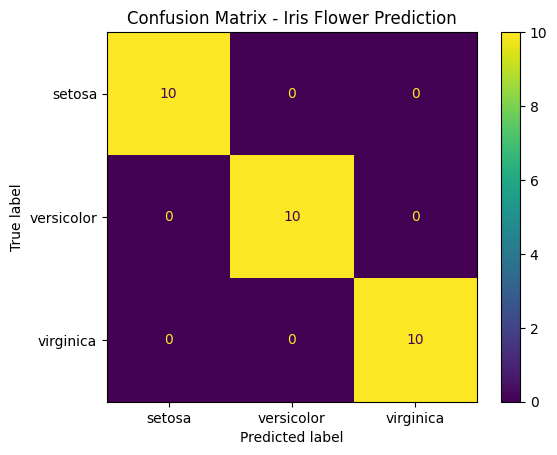

In [26]:
# Visualize the confusion matrix

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

display.plot()
plt.title("Confusion Matrix - Iris Flower Prediction")
plt.show()

# Confusion Matrix Insight

From the confusion matrix, I can see that the model predicted most flowers correctly, but it made a small mistake by confusing one flower species with another. This can happen when two flower types have similar measurements.

From the confusion matrix, I can see how many flowers were correctly predicted for each species.

The diagonal values show the correct predictions.

If there are no values outside the diagonal, it means the model did not confuse the flower species in this test set.

This shows that the model worked very well on this small and clean dataset.

# Classification Report

The classification report gives more details about the model performance.

It shows precision, recall, F1-score, and support.

Precision tells me how reliable the model is when it predicts a class.

Recall tells me how well the model finds all actual samples of a class.

In [27]:
# Print classification report

print(classification_report(
    y_test,
    predictions,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Evaluation Insight

The model performed very well on the test data.

The accuracy was high, and the confusion matrix showed that the model correctly predicted most or all flower species.

The classification report also showed strong precision and recall values.

This means the model was able to learn useful patterns from the flower measurements.

However, I should still remember that this is a small and clean beginner dataset. Real-world datasets may have more noise, missing values, and unclear patterns.

# Conclusion

This project helped me complete my first end-to-end machine learning pipeline.

I started by understanding the dataset, checking and preparing the data, identifying X and y, splitting the data, training a model, making predictions, and evaluating the results.

The model worked very well on the Iris dataset.

I would trust this model for this small beginner dataset because the data is clean and balanced.

## Limitation

One limitation is that the Iris dataset is small and already clean.

Because of this, the model may look very strong in this project, but real-world data can be more difficult.

## Idea to Improve

One way to improve this project in the future is to try different models, such as Decision Tree or Logistic Regression, and compare their performance.

Another improvement is to test the model on a larger or more realistic dataset.